In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import OneHotEncoder

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

## Making categorical data numerical

In [4]:
drop_feat = np.array(['Name','Ticket','Cabin','Fare'])

In [5]:
ohe = OneHotEncoder(sparse_output=False)

In [6]:
def clean(df):
    df = df.drop(drop_feat,axis = 1)
    df['Embarked'] = df['Embarked'].fillna('S')
    df = pd.concat([df,pd.DataFrame(ohe.fit_transform(df[['Embarked']]))],axis = 1)
    df = df.rename({0:'C',1:'S',2:'Q'},axis = 1)
    df = df.drop(['Embarked'],axis = 1)

    
    df['Age'] = df['Age'].fillna(df['Age'].median())
    temp = np.array([])
    for i in df['Sex']:
        if i == 'female':
            temp = np.append(temp,0)
        elif i == 'male':
            temp = np.append(temp,1)
        df['Sex'] = pd.DataFrame(temp)
    return df

In [7]:
test_df = clean(test_df)
train_df = clean(train_df)

In [8]:
train_df.head()
#Male=0 and Female=1

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,C,S,Q
0,1,0,3,1.0,22.0,1,0,0.0,0.0,1.0
1,2,1,1,0.0,38.0,1,0,1.0,0.0,0.0
2,3,1,3,0.0,26.0,0,0,0.0,0.0,1.0
3,4,1,1,0.0,35.0,1,0,0.0,0.0,1.0
4,5,0,3,1.0,35.0,0,0,0.0,0.0,1.0


In [9]:
#total
train_df['Sex'].size

891

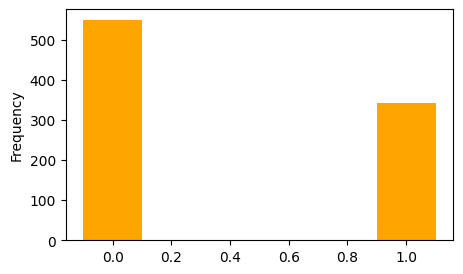

In [10]:
train_df['Survived'].plot(kind = 'hist',bins = [-0.5,0.5,1.5],rwidth = 0.2,color = 'orange',figsize = (5,3))
plt.show()

#### The above histogram shows the number of people who survived and who didn't

In [11]:
train_df_survived = pd.DataFrame({'Survived':np.array([]),
                                  'Pclass':np.array([]),
                                  'Sex':np.array([]),
                                  'Age':np.array([]),
                                  'SibSp':np.array([]),
                                  'Parch':np.array([]),
                                  'C':np.array([]),
                                  'S':np.array([]),
                                  'Q':np.array([])})

train_df_not_survived = pd.DataFrame({'Survived':np.array([]),
                                  'Pclass':np.array([]),
                                  'Sex':np.array([]),
                                  'Age':np.array([]),
                                  'SibSp':np.array([]),
                                  'Parch':np.array([]),
                                  'C':np.array([]),
                                  'S':np.array([]),
                                  'Q':np.array([])})

In [12]:
n = train_df['Survived'].size
for i,j in zip(range(n),train_df['Survived']):
    if j == 1:
        train_df_survived = pd.concat([train_df_survived,train_df.iloc[[i]]],ignore_index = True)
    elif j == 0:
        train_df_not_survived = pd.concat([train_df_not_survived,train_df.iloc[[i]]],ignore_index = True)        

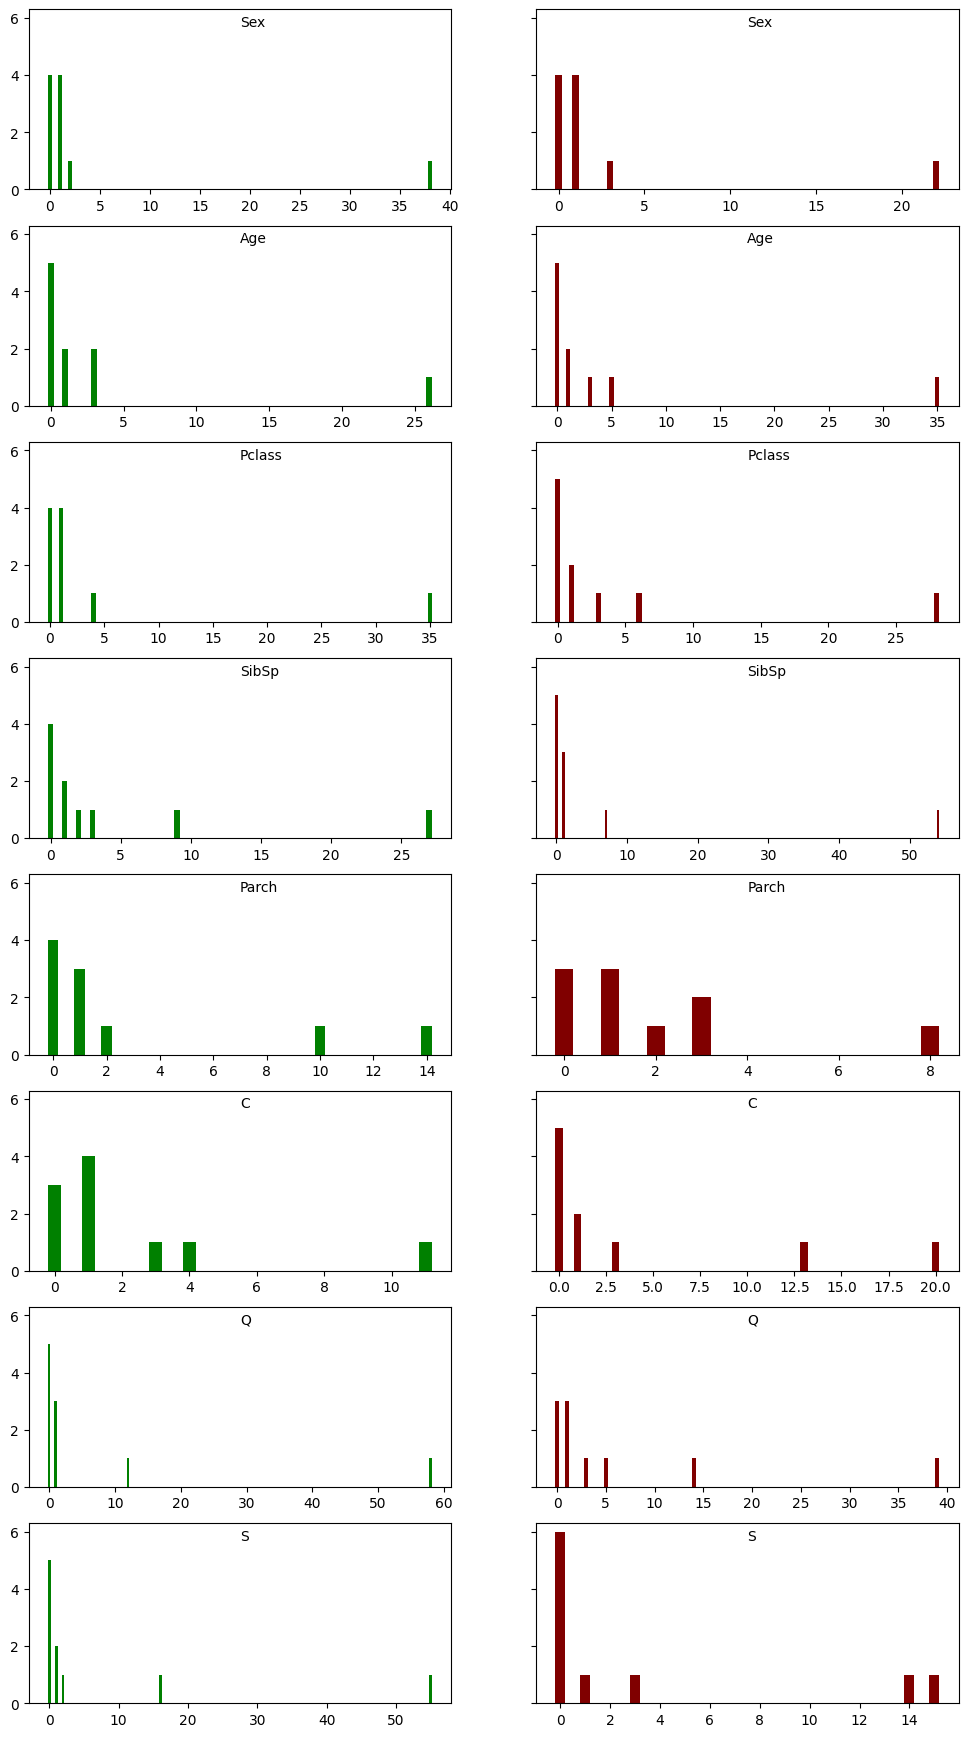

In [46]:
#Looks dirty
features = np.array(['Sex','Age','Pclass','SibSp','Parch','C','Q','S'])
fig,axes = plt.subplots(8,2,sharey=True,figsize = (12,22))
count = 0
for i in range(8):
    for j in range(2):
        if j % 2 == 0:
            axes[i,j].hist(train_df_survived.iloc[count],bins = np.arange(train_df_survived.iloc[count].min(),train_df_survived.iloc[count].max() + 2) - 0.5,rwidth = 0.4,color = 'green')
            axes[i,j].annotate(features[count],xy = ((train_df_survived.iloc[count].min() + train_df_survived.iloc[count].max())/2,5.7))
        else:
            axes[i,j].hist(train_df_not_survived.iloc[count],bins = np.arange(train_df_not_survived.iloc[count].min(),train_df_not_survived.iloc[count].max() + 2) - 0.5,rwidth = 0.4,color = 'maroon')
            axes[i,j].annotate(features[count],xy = (((train_df_not_survived.iloc[count].min() + train_df_not_survived.iloc[count].max())/2,5.7)))
    count += 1
plt.show()

In [15]:
def predict_survivor(data):
    y = pd.DataFrame({'PassengerId':[],'Survived':[]})
    for pass_id,sex in zip(data['PassengerId'],data['Sex']):
        if sex == 0:
            temp = pd.DataFrame({'PassengerId':pass_id,'Survived':random.choices(population = [0,1], weights = [14.75,68.13])})
            y = pd.concat([y,temp],ignore_index=True)
        elif sex == 1:
            temp = pd.DataFrame({'PassengerId':str(pass_id),'Survived':random.choices(population = [0,1], weights = [85.24,31.87])})
            y = pd.concat([y,temp],ignore_index=True)
    return y.copy()